# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
pip install -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple nba-draft-predictor==0.2.5

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple
Note: you may need to restart the kernel to use updated packages.


---
## A. Project Description


In [5]:
# <Student to fill this section>
student_name = "Pranav Sathyababu"
student_id = "25588726"
group_id = "24"

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [8]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [9]:
business_use_case_description = """
This project predicts the likelihood that a college or international basketball player will be drafted into the NBA based on performance, efficiency, and contextual attributes. The goal is to prioritize scouting resources, surface undervalued prospects earlier, and support data-driven draft decisions. By producing a ranked list with probabilities, the model helps front-office and scouting teams focus film study and workouts on the highest-upside players while quantifying risk.
"""


In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:
business_objectives = """
Accurate results will provide NBA teams with a reliable, data-driven tool to prioritize scouting
resources, identify undervalued prospects, and reduce uncertainty in draft decisions. This could
lead to better talent acquisition, stronger team performance, and long-term competitive advantage.
On the other hand, incorrect or misleading results could waste scouting resources, cause teams to
overlook high-potential players, or invest in players with low actual value. Therefore, accuracy is
critical, as the stakes of draft decisions involve multimillion-dollar contracts and the future
trajectory of a franchise.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
stakeholders_expectations_explanations = """
The results of this project will be used by NBA front-office executives, coaches, and scouting
departments to guide draft decision-making. The primary users of the predictions are scouts and
analysts who can combine model outputs with traditional evaluation methods to create a more
balanced and objective player assessment. Accurate predictions can also impact agents and players,
as strong draft likelihood scores may influence contract negotiations or player development focus.
Ultimately, team ownership and fans are indirectly impacted, since draft outcomes shape the long-term
success of a franchise. The model is therefore expected to be a complementary decision-support tool
that provides probabilistic insights rather than replacing human expertise.
"""

In [14]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [15]:
X_train = pd.read_csv("../../data/processed/X_train.csv")
y_train = pd.read_csv("../../data/processed/y_train.csv")
X_val   = pd.read_csv("../../data/processed/X_val.csv")
y_val   = pd.read_csv("../../data/processed/y_val.csv")
X_test  = pd.read_csv("../../data/processed/X_test.csv")


train_df = pd.read_csv("../../data/raw/train.csv")
test_df  = pd.read_csv("../../data/raw/test.csv")


---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [16]:
# <Student to fill this section>
performance_metrics_explanations = """
Since this is a binary classification problem (drafted vs not drafted) and the dataset is highly imbalanced (very few players are drafted compared to not drafted), we need performance metrics that go beyond accuracy.
AUROC (Area Under the ROC Curve): Best metric here, because it measures how well the model distinguishes between classes regardless of threshold. It is insensitive to class imbalance and widely used in imbalanced problems.
"""

In [17]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

In [18]:
import sys
print(sys.executable)


C:\Users\prana\advmla_assignment_1\.venv\Scripts\python.exe


## J. Train Machine Learning Model - LightGBM

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [19]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [20]:
algorithm_selection_explanations = """
LightGBM is a good fit for this project because it is a gradient boosting framework that is highly 
efficient on large, tabular datasets with mixed feature types. It can naturally handle non-linear 
relationships, feature interactions, and missing values, which are common in player performance data. 
LightGBM also supports class imbalance handling through parameters like scale_pos_weight, making it 
well-suited for predicting rare events such as being drafted. Compared to traditional models, it 
offers faster training, lower memory usage, and strong predictive performance, while still allowing 
interpretability through feature importance. These properties make LightGBM an appropriate algorithm 
for building a robust and scalable draft prediction system.
"""

In [21]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [22]:
final_lgbm = LGBMClassifier(
    subsample=0.7,
    num_leaves=63,
    n_estimators=800,
    min_child_samples=25,
    max_depth=12,
    learning_rate=0.02,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=2.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


In [23]:
hyperparameters_selection_explanations = """
The hyperparameters were tuned to balance model complexity, generalization, and the dataset’s class 
imbalance. The learning_rate (0.02) was set low to ensure gradual learning, combined with a higher 
n_estimators (800) to allow the model to converge effectively. num_leaves and max_depth were tuned 
to control the complexity of individual trees and prevent overfitting while still capturing important 
feature interactions. min_child_samples and subsample/colsample_bytree introduce regularization by 
requiring sufficient data in leaves and randomly sampling rows and features, which improves 
generalization. reg_alpha and reg_lambda apply L1 and L2 penalties to further reduce overfitting. 
Finally, class_weight='balanced' automatically adjusts for the skewed distribution of drafted versus 
non-drafted players, ensuring the minority class is properly represented in training. Together, these 
choices make the model both accurate and robust for predicting draft outcomes.
"""

In [24]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [25]:
# Train
final_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 78, number of negative: 9637
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000589 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4230
[LightGBM] [Info] Number of data points in the train set: 9715, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

LGBMClassifier(class_weight='balanced', colsample_bytree=0.6,
               learning_rate=0.02, max_depth=12, min_child_samples=25,
               n_estimators=800, n_jobs=-1, num_leaves=63, random_state=42,
               reg_alpha=0.1, reg_lambda=2.0, subsample=0.7)

### J.4 Model Technical Performance

> Provide some explanations on model performance


Train AUROC: 1.0
Valid AUROC: 0.9624372133653636

Validation Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      2410
         1.0       0.39      0.63      0.48        19

    accuracy                           0.99      2429
   macro avg       0.69      0.81      0.74      2429
weighted avg       0.99      0.99      0.99      2429


Validation Confusion Matrix:
[[2391   19]
 [   7   12]]


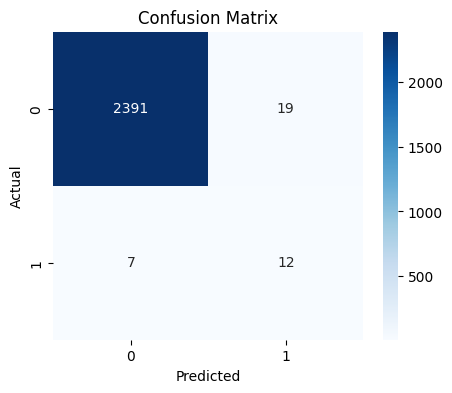

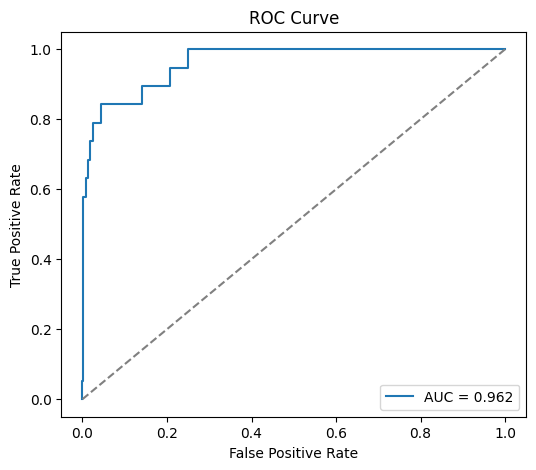

In [26]:
from nba_draft_predictor import evaluate_model, plot_confusion_matrix, plot_roc_curve

# Text-based evaluation
evaluate_model(final_lgbm, X_train, y_train, X_val, y_val)

# Confusion Matrix
y_val_pred = final_lgbm.predict(X_val)
plot_confusion_matrix(y_val, y_val_pred, labels=[0, 1])

# ROC Curve
y_val_proba = final_lgbm.predict_proba(X_val)[:, 1]
plot_roc_curve(y_val, y_val_proba)


In [27]:
model_performance_explanations = """
The model achieved strong overall performance, with a validation AUROC of 0.962, showing excellent 
ability to distinguish between drafted and non-drafted players. The majority class (not drafted) 
was predicted with near-perfect precision and recall, reflecting the large representation of this 
class in the dataset. However, performance on the minority class (drafted players) was more modest, 
with precision of 0.39 and recall of 0.63. This indicates that while the model correctly identifies 
most drafted players, it also produces a number of false positives. Given the business context, this 
trade-off is acceptable, as it is more valuable to over-identify potential prospects (ensuring fewer 
are missed) than to risk overlooking players who will actually be drafted. Overall, the model 
generalizes well and provides actionable insights, though further improvements could focus on 
boosting minority class precision without sacrificing recall.
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

In [29]:
from nba_draft_predictor import  make_submission_xlsx

submission = make_submission_xlsx(final_lgbm, X_test, test_df, "submission.xlsx")
submission.head()

submission.xlsx created


,player_id,drafted
0,c6d3ce49-28b6-4756-8061-b2bd68730c52,0.000050
1,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5,0.000049
2,0cf3e822-9446-4285-b7ed-7c19d8e976fe,0.000706
3,b1a88de0-6852-4597-bb92-9164b40758e5,0.000056
4,97c327ce-d051-40f0-9166-1a43557c3c92,0.000169


### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [30]:
business_impacts_explanations = """
The results suggest that the model is highly effective at distinguishing drafted from non-drafted 
players, with a validation AUROC of 0.962. For the business objective, this means that front offices 
can rely on the model to prioritize scouting resources towards players with a high likelihood of 
being drafted. Accurate results reduce wasted resources and increase the chance of identifying 
undervalued prospects earlier. However, the model shows limitations with the minority class, where 
precision is lower (0.39), leading to some false positives. In business terms, this means that some 
non-drafted players may be incorrectly flagged as high-potential prospects, potentially consuming 
additional scouting time and effort. While this inefficiency carries some cost, it is less damaging 
than false negatives (missing true drafted players), which the model keeps relatively low. Missing 
true drafted players could result in lost opportunities to recruit valuable talent, directly 
impacting a team's competitiveness and long-term success. Therefore, even with imperfect precision, 
the model aligns with business priorities by ensuring that promising talent is rarely overlooked, 
though future improvements should aim to reduce false positives to optimize resource allocation.
"""

In [31]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [32]:
experiment_outcome = "Hypothesis Partially Confirmed"

In [33]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [34]:
experiment_results_explanations = """
The experiment achieved strong results (AUROC 0.962), confirming that player statistics can predict 
draft likelihood. The model is highly accurate for non-drafted players but less precise for drafted 
players, highlighting the impact of class imbalance. 

Key insights: the approach is effective, but improvements are needed to reduce false positives. 
Next steps include threshold tuning (moderate gain), resampling or cost-sensitive learning (high 
gain), and feature engineering (moderate gain). If the main goal is to avoid missing true prospects, 
the model is already valuable and could be deployed as a decision-support tool, with further 
iterations aimed at boosting precision. Experiment 3 (LightGBM) also achieved excellent AUROC and efficiency, though recall for drafted 
players was lower than Random Forest. The next step would be to return to boosting with XGBoost for 
finer-grained regularization, or to explore hybrid ensembles that combine the strengths of Random 
Forest and boosting approaches.
"""

In [35]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)